# 12. Joint Optimization: FWHM + Sigma Matching

**Goal:** jointly optimize μ and γ by matching **both** the FWHM distribution and the fit-uncertainty distribution.

| Gradient | Source | Why |
|---|---|---|
| **μ** (REINFORCE) | Per-quantile reward: −W₁(FWHM) − λ·W₁(σ) | σ encodes photon count statistics directly |
| **γ** (implicit diff) | dLoss/dγ = W₁'(FWHM)·dFWHM/dγ + λ·W₁'(σ)·dσ/dγ | Matching both tightens γ constraints |

**dσ/dγ** is approximated via CRLB: σ ≈ 2γ/√n → dσ/dγ ≈ 2/√n.

All model code from `src/`.

In [1]:
import sys
sys.path.insert(0, "/home/pukky/.openclaw/workspace/qm-ml")
import math, time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

from src.fitting import (
    _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile
)
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
GAMMA_TRUE = 20.0
NBAR_TRUE = 50.0
LAMBDA_ = 2.0

N_TARGET = 200
N_RUNS = 200
N_ITER = 80

SIGMA_PROP = 6.0          # physical noise std
LR_MU = 15.0              # learning rate for mu
LR_GAMMA = 0.5            # learning rate for gamma
BASELINE_ALPHA = 0.05     # EMA smoothing
CLIP = 10.0               # gradient clipping

LAMBDA_SIGMA = 0.3        # weight for sigma term in loss/reward
LAMBDA_GAMMA_SIGMA = 0.3  # weight for sigma term in gamma gradient
LAMBDA_MEAN = 5.0        # weight for mean FWHM matching

MU_INIT = 30.0
GAMMA_INIT = 15.0
SEED = 42

print('Parameters set')

Parameters set


## Generate Target Data

Collect both FWHM and sigma_FWHM at true (μ=50, γ=20).

In [3]:
t_total = time.time()

# Build fit/nll/fwhm wrappers (Lorentzian, no background)
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

df = pd.read_csv('/home/pukky/.openclaw/workspace/qm-ml/data/processed/fwhm_linewidths.csv')
SCALE = 1000.0
cond = (df['power_nW'] == 3) & (df['transmission'] == 40)
sub = df[cond].dropna(subset=['fwhm', 'fit_error'])
err_max = np.percentile(sub['fit_error'].values, 99)
sub = sub[sub['fit_error'] <= err_max]
target_raw = sub['fwhm'].values * SCALE
target_fit_err = sub['fit_error'].values * SCALE
target_data = torch.tensor(target_raw, dtype=torch.float32)
N_TARGET = len(target_data)

target_fwhms = target_data.tolist()
target_sigmas = target_fit_err.tolist()

print(f'Target: {N_TARGET} FWHM values from real data (3nW, 40% transmission)')
print(f'  FWHM mean: {target_data.mean():.2f}, std: {target_data.std():.2f}')
print(f'  Sigma mean: {np.mean(target_fit_err):.4f}, std: {np.std(target_fit_err):.4f}')
print(f'  Range FWHM: [{target_data.min():.2f}, {target_data.max():.2f}]')
print(f'  Range sigma: [{np.min(target_fit_err):.4f}, {np.max(target_fit_err):.4f}]')

target_t = torch.tensor(target_fwhms, dtype=torch.float32)
target_s_t = torch.tensor(target_sigmas, dtype=torch.float32)
st = torch.sort(target_t)[0]
st_sig = torch.sort(target_s_t)[0]





Target: 3725 FWHM values from real data (3nW, 40% transmission)
  FWHM mean: 26.89, std: 10.18
  Sigma mean: 2.2118, std: 3.3675
  Range FWHM: [0.88, 89.94]
  Range sigma: [0.1866, 42.4740]


## Joint Optimization: FWHM + Sigma

### μ update (REINFORCE)
Per-quantile reward combines FWHM and sigma matches, using `adv = loss - baseline` for consistent signs:
```
cl_i = |FWHM_(i) - target_(i)| + λ_sig · |σ_(i) - σ_target_(i)|
adv_i = cl_i - baseline
∇_μ = mean(adv_i × (n_i − μ) / σ²)
```

### γ update (implicit diff + CRLB)
```
∇γ_FWHM  = mean(sign(FWHM_i − target_i) × dFWHM_i/dγ)
∇γ_sigma = mean(sign(σ_i − σ_target_i) × dσ_i/dγ)    # dσ/dγ ≈ 2/√n
∇γ = ∇γ_FWHM + λ · ∇γ_sigma
```

In [4]:
mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
bl = 0.0
history = []

print(f"μ_init={MU_INIT}, γ_init={GAMMA_INIT}, true=({NBAR_TRUE},{GAMMA_TRUE})")
print(f"N_ITER={N_ITER}, N_RUNS={N_RUNS}, λ_sig={LAMBDA_SIGMA}, λ_γ_sig={LAMBDA_GAMMA_SIGMA}\n")
LAMBDA_MEAN = 5.0        # weight for mean FWHM matching

for step in range(N_ITER):
    rng2 = np.random.default_rng(SEED + step)
    fwhms, sigmas, dfs, ns = [], [], [], []
    
    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
        ns.append(n)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_val, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2
        )
        fwhms.append(fw)
        sigmas.append(sig)
        dfs.append(dg)
    
    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    
    # Sorted quantile matching
    sf, sidx = torch.sort(ft)
    pl = torch.abs(sf - st[:N_RUNS])           # FWHM loss per quantile
    nss = nt[sidx]                               # n sorted by FWHM rank
    dgs = dg_t[sidx]                             # dFWHM/dγ sorted by FWHM rank
    ss = si_t[sidx]                              # σ sorted by FWHM rank
    
    # Sigma loss per quantile (same sort order)
    pl_sig = torch.abs(ss - st_sig[:N_RUNS])
    # Mean-matching loss
    mean_fwhm_loss = torch.abs(ft.mean() - target_t.mean())
    
    # Combined per-quantile loss (positive, used for both baseline and adv)
    cl = pl + LAMBDA_SIGMA * pl_sig
    
    loss_fwhm = pl.mean()
    loss_sigma = pl_sig.mean()
    mean_loss = (loss_fwhm + LAMBDA_SIGMA * loss_sigma + LAMBDA_MEAN * mean_fwhm_loss).item()
    mean_fwhm_loss_val = mean_fwhm_loss.item()
    loss_fwhm_val = loss_fwhm.item()
    loss_sigma_val = loss_sigma.item()
    
    # Baseline
    if step == 0:
        bl = mean_loss
    else:
        bl = (1 - BASELINE_ALPHA) * bl + BASELINE_ALPHA * mean_loss
    
    # ---- MU gradient: REINFORCE ----
    # FIXED: adv = combined_loss - baseline (consistent signs)
    adv = (cl.detach() - bl).numpy()
    scores = (nss.numpy() - mu_val) / SIGMA_PROP**2
    raw_grad_mu = float(np.mean(adv * scores))
    grad_mu = max(min(raw_grad_mu, CLIP), -CLIP)
    mu_val += LR_MU * (-grad_mu)
    mu_val = max(1.0, min(200.0, mu_val))
    
    # ---- GAMMA gradient: implicit diff (FWHM) + CRLB (sigma) ----
    # dσ/dγ per run: CRLB ≈ 2/√n
    dsigs = torch.tensor([min(2.0 / math.sqrt(max(int(n), 1)), 2.0) for n in ns], dtype=torch.float32)
    ds_s = dsigs[sidx]
    
    signs_fw = torch.sign(sf - st[:N_RUNS])
    signs_sg = torch.sign(ss - st_sig[:N_RUNS])
    raw_grad_fwhm = float((signs_fw * dgs).mean().item())
    raw_grad_sigma = float((signs_sg * ds_s).mean().item())
    raw_grad_gamma = raw_grad_fwhm + LAMBDA_GAMMA_SIGMA * raw_grad_sigma
    grad_gamma = max(min(raw_grad_gamma, CLIP), -CLIP)
    gamma_val += LR_GAMMA * (-grad_gamma)
    gamma_val = max(0.1, min(100.0, gamma_val))
    
    # Diagnostics
    rho = float(np.corrcoef(nss.numpy(), pl.numpy())[0, 1]) if pl.std() > 0.01 and nss.std() > 0.01 else 0.0
    
    info = {
        'step': step,
        'mu': mu_val, 'gamma': gamma_val,
        'loss': mean_loss, 'loss_fwhm': loss_fwhm_val, 'loss_sigma': loss_sigma_val,
        'baseline': bl,
        'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
        'rho': rho, 'mean_n': float(np.mean(ns)),
        'mean_fwhm': float(ft.mean().item()),
        'mean_sigma': float(ss.mean().item()),
    }
    history.append(info)
    
    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: μ={mu_val:6.2f} γ={gamma_val:5.1f} | "
              f"L={mean_loss:.2f}(F={loss_fwhm_val:.2f}+S={loss_sigma_val:.2f}) | "
              f"∇μ={grad_mu:+.4f} ∇γ={grad_gamma:+.4f} | "
              f"n̄={info['mean_n']:4.1f} ρ={rho:+.3f} "
              f"({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

μ_init=30.0, γ_init=15.0, true=(50.0,20.0)
N_ITER=80, N_RUNS=200, λ_sig=0.3, λ_γ_sig=0.3



  S 0: μ= 30.34 γ= 13.9 | L=54.04(F=21.99+S=1.36) | ∇μ=-0.0225 ∇γ=+2.2707 | n̄=29.8 ρ=-0.129 (4s)


  S 5: μ= 60.55 γ=  8.2 | L=47.38(F=7.74+S=0.06) | ∇μ=-0.1797 ∇γ=+2.0654 | n̄=58.0 ρ=-0.138 (20s)


  S10: μ= 53.51 γ=  5.2 | L=74.51(F=1.06+S=0.10) | ∇μ=-0.1363 ∇γ=+1.0111 | n̄=51.5 ρ=-0.026 (34s)


  S15: μ= 54.61 γ=  4.6 | L=72.83(F=1.46+S=0.45) | ∇μ=-1.9677 ∇γ=+1.6959 | n̄=26.2 ρ=-0.380 (48s)


...

  S65: μ=149.92 γ=  5.9 | L=75.23(F=1.10+S=0.34) | ∇μ=+1.5877 ∇γ=-0.0623 | n̄=173.0 ρ=-0.035 (191s)


  S70: μ=155.46 γ=  6.1 | L=76.87(F=1.08+S=0.34) | ∇μ=+0.7579 ∇γ=-0.6484 | n̄=166.5 ρ=-0.043 (206s)


  S75: μ=182.39 γ=  5.8 | L=74.75(F=1.06+S=0.32) | ∇μ=-1.9012 ∇γ=+0.3202 | n̄=154.8 ρ=-0.120 (220s)


  S79: μ=185.93 γ=  5.6 | L=74.14(F=1.16+S=0.34) | ∇μ=-0.8464 ∇γ=+0.8833 | n̄=173.7 ρ=+0.027 (231s)



Done. 231s


## Results

In [5]:
if len(history) > 0:
    fmu = history[-1]['mu']
    fga = history[-1]['gamma']
    print(f"{'='*65}")
    print(f"  JOINT OPTIMIZATION — FWHM + SIGMA MATCHING")
    print(f"{'='*65}")
    print(f"  μ:     {MU_INIT:.0f} → {fmu:.2f}  (true={NBAR_TRUE})  error={abs(fmu-NBAR_TRUE):.2f}")
    print(f"  γ:     {GAMMA_INIT:.0f} → {fga:.2f}  (true={GAMMA_TRUE})  error={abs(fga-GAMMA_TRUE):.2f}")
    print(f"  Loss:  {history[0]['loss']:.2f} → {history[-1]['loss']:.2f}")
    print(f"  FWHM:  {history[0]['loss_fwhm']:.2f} → {history[-1]['loss_fwhm']:.2f}")
    print(f"  Sigma: {history[0]['loss_sigma']:.2f} → {history[-1]['loss_sigma']:.2f}")
    print(f"  μ final grad: {history[-1]['grad_mu']:+.4f}")
    print(f"  Time:  {time.time()-t_total:.0f}s")
    print(f"{'='*65}")

  JOINT OPTIMIZATION — FWHM + SIGMA MATCHING
  μ:     30 → 185.93  (true=50.0)  error=135.93
  γ:     15 → 5.62  (true=20.0)  error=14.38
  Loss:  54.04 → 74.14
  FWHM:  21.99 → 1.16
  Sigma: 1.36 → 0.34
  μ final grad: -0.8464
  Time:  231s


## Visualization for Presentation

### μ and γ convergence + trajectory + FWHM distribution comparison

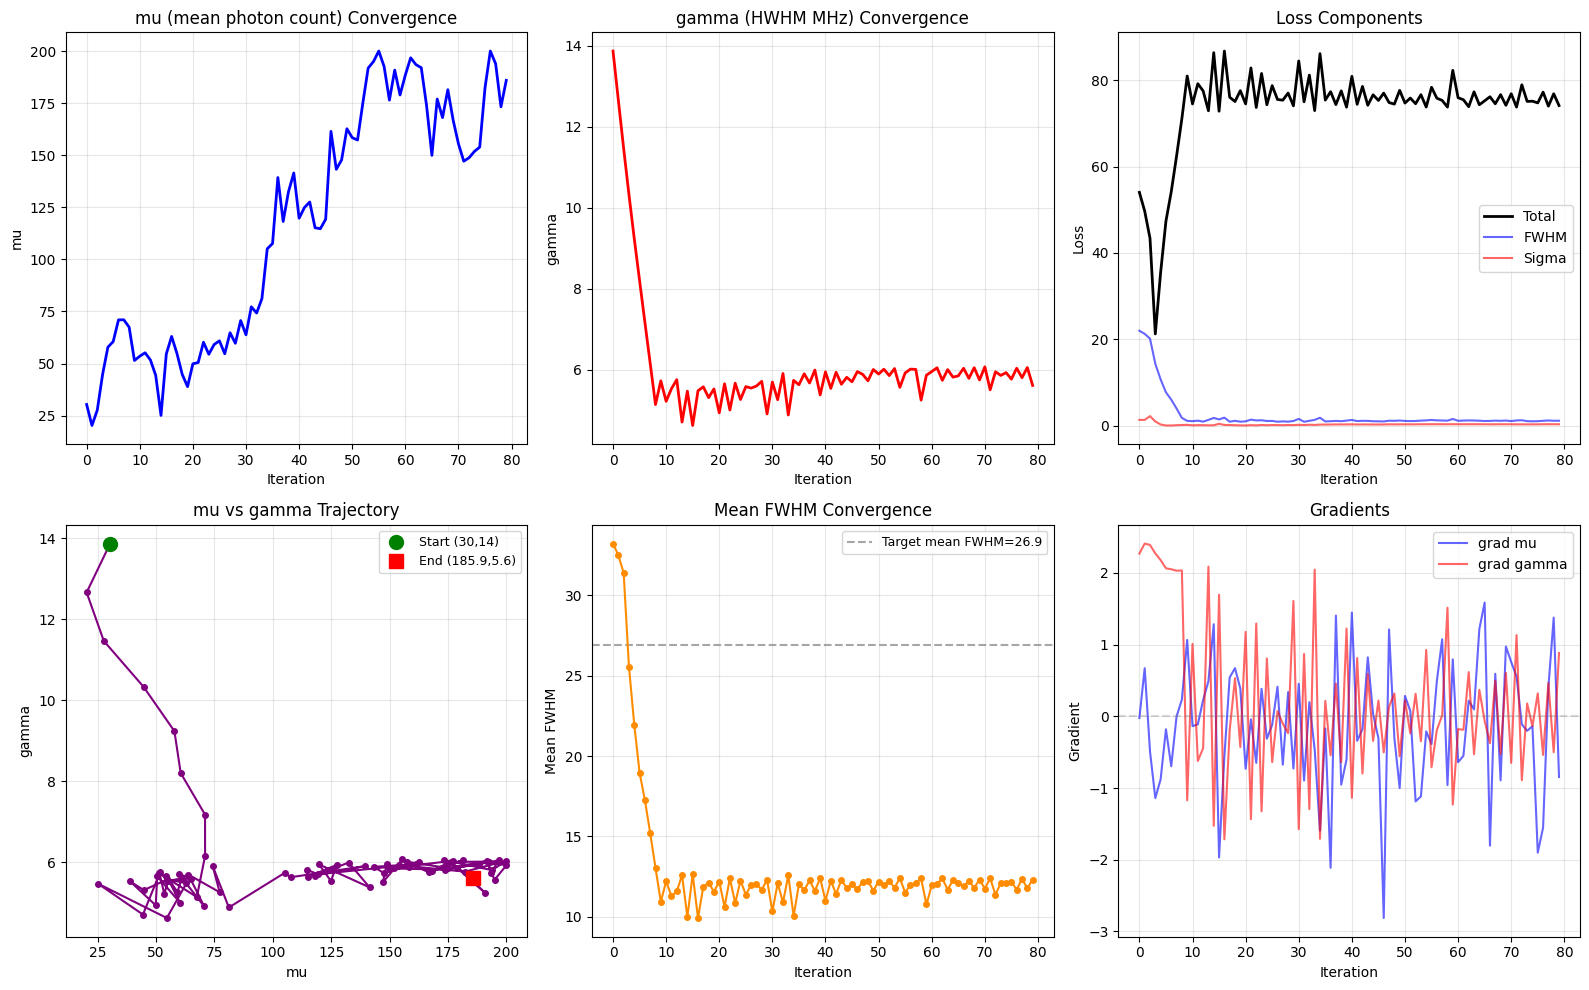

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from src.losses import wasserstein_loss

steps = [h['step'] for h in history]
mu_hist = [h['mu'] for h in history]
gamma_hist = [h['gamma'] for h in history]
loss_hist = [h['loss'] for h in history]
loss_f_hist = [h['loss_fwhm'] for h in history]
loss_s_hist = [h['loss_sigma'] for h in history]
mean_fwhm_hist = [h['mean_fwhm'] for h in history]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- mu convergence ---
ax = axes[0, 0]
ax.plot(steps, mu_hist, 'b-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('mu')
ax.set_title('mu (mean photon count) Convergence'); ax.grid(alpha=0.3)

# --- gamma convergence ---
ax = axes[0, 1]
ax.plot(steps, gamma_hist, 'r-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('gamma')
ax.set_title('gamma (HWHM MHz) Convergence'); ax.grid(alpha=0.3)

# --- Loss components ---
ax = axes[0, 2]
ax.plot(steps, loss_hist, 'k-', linewidth=2, label='Total')
ax.plot(steps, loss_f_hist, 'b-', alpha=0.6, label='FWHM')
ax.plot(steps, loss_s_hist, 'r-', alpha=0.6, label='Sigma')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('Loss Components'); ax.legend(); ax.grid(alpha=0.3)

# --- mu vs gamma trajectory ---
ax = axes[1, 0]
ax.plot(mu_hist, gamma_hist, 'o-', color='purple', markersize=4, linewidth=1.5)
ax.plot(mu_hist[0], gamma_hist[0], 'go', markersize=10, label=f'Start ({mu_hist[0]:.0f},{gamma_hist[0]:.0f})')
ax.plot(mu_hist[-1], gamma_hist[-1], 'rs', markersize=10, label=f'End ({mu_hist[-1]:.1f},{gamma_hist[-1]:.1f})')
ax.set_xlabel('mu'); ax.set_ylabel('gamma')
ax.set_title('mu vs gamma Trajectory'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# --- Mean FWHM ---
ax = axes[1, 1]
target_mean = target_t.mean().item()
ax.axhline(target_mean, color='gray', ls='--', linewidth=1.5, alpha=0.7, label=f'Target mean FWHM={target_mean:.1f}')
ax.plot(steps, mean_fwhm_hist, 'o-', color='darkorange', markersize=4)
ax.set_xlabel('Iteration'); ax.set_ylabel('Mean FWHM')
ax.set_title('Mean FWHM Convergence'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# --- Gradient norms ---
ax = axes[1, 2]
grad_mu = [h['grad_mu'] for h in history]
grad_gamma = [h['grad_gamma'] for h in history]
ax.plot(steps, grad_mu, 'b-', alpha=0.6, label='grad mu')
ax.plot(steps, grad_gamma, 'r-', alpha=0.6, label='grad gamma')
ax.axhline(0, color='gray', ls='--', alpha=0.3)
ax.set_xlabel('Iteration'); ax.set_ylabel('Gradient')
ax.set_title('Gradients'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Generating final forward pass for distribution comparison...


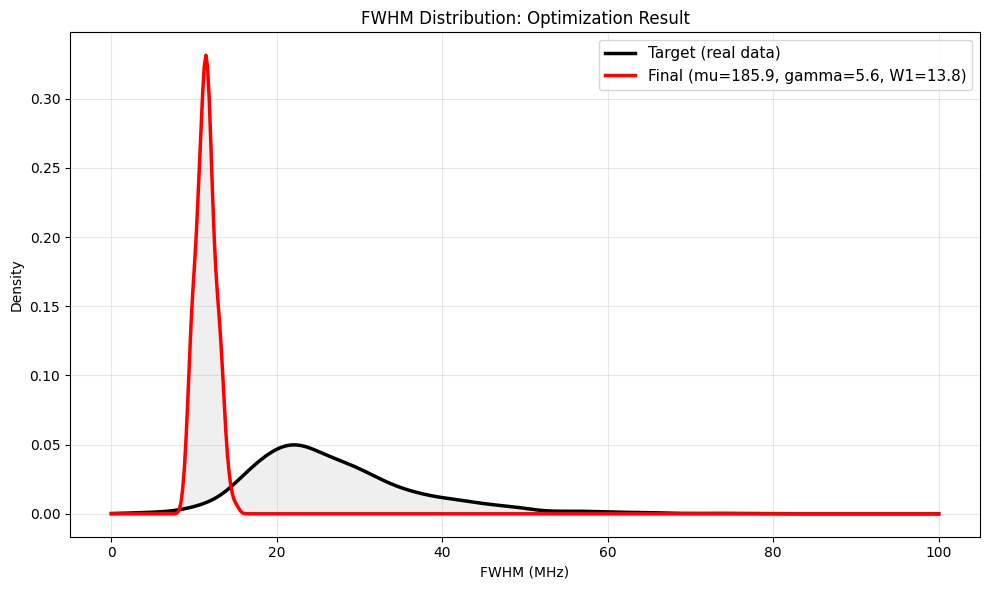

Target FWHM: 26.9 +/- 10.2
Final  FWHM: 11.4 +/- 1.2


In [7]:
# Final forward pass for FWHM distribution comparison
print('Generating final forward pass for distribution comparison...')
rng_f = np.random.default_rng(999)
final_fwhms = []
for _ in range(500):
    u, b, n = draw_fixed_noise(mu_hist[-1], SIGMA_PROP, LAMBDA_, rng_f)
    photons = build_photons(torch.tensor(gamma_hist[-1], dtype=torch.float32), u, b)
    theta = fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)
    if theta is not None:
        final_fwhms.append(fwhm_from_theta(theta, model='lorentzian').item())
    else:
        final_fwhms.append(2.0 * gamma_hist[-1])
final_t = torch.tensor(final_fwhms, dtype=torch.float32)

# Target vs Final KDE (initial pass skipped for real data)
x_grid = np.linspace(0, 100, 500)
kde_target = gaussian_kde(target_t.numpy())
kde_final = gaussian_kde(final_t.numpy())
w1_final = wasserstein_loss(final_t, target_t).item()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label='Target (real data)')
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Final (mu={mu_hist[-1]:.1f}, gamma={gamma_hist[-1]:.1f}, W1={w1_final:.1f})')
ax.fill_between(x_grid, kde_final(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title('FWHM Distribution: Optimization Result')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Target FWHM: {target_t.mean():.1f} +/- {target_t.std():.1f}')
print(f'Final  FWHM: {final_t.mean():.1f} +/- {final_t.std():.1f}')
